# B.3 工具結果怎麼回到對話？


工具已算123×45=5535，下一站要把這個**真返回值**交給模型，再生成最後回答。請求與結果各有來源：assistant提出要做什麼，外層程式實際回了什麼。這份按順序留下的紀錄叫trace。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

In [2]:
from tiny_perceptron.retrieval import call_tool

request = {"name": "multiply", "arguments": {"a": 123, "b": 45}}
result = call_tool(request)
trace = [
    {"role": "assistant", "tool_request": request},
    {"role": "tool", "result": result},
]
print("返回值", result)
print("將送回對話的兩筆紀錄", trace)
assert result == 5535

返回值 5535
將送回對話的兩筆紀錄 [{'role': 'assistant', 'tool_request': {'name': 'multiply', 'arguments': {'a': 123, 'b': 45}}}, {'role': 'tool', 'result': 5535}]


請求是人工指定，`result`則來自真正 `call_tool`。第一行5535，assert核對乘法。這段只建立外層紀錄，沒有最後模型回答。把b改46，再把assert改5658，工具與trace應同步變，不能繼續引用舊5535。


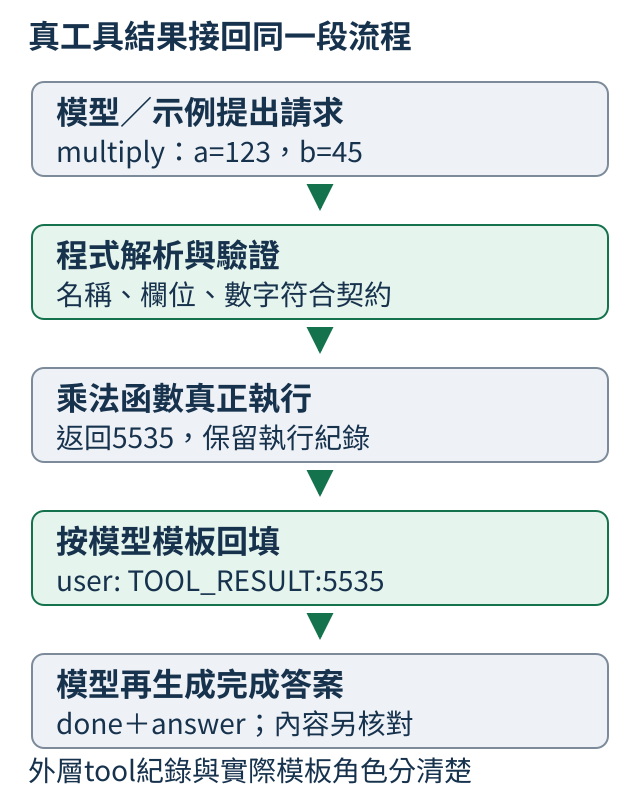

In [3]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-B-tool-flow.svg")))

圖中的回填是模型接受的訊息格式。這裏要區分兩種表示：短例的tool角色只是外層Python紀錄；現有 `render_chat` 只接受system、user、assistant，因此正式局部流程用user文字 `TOOL_RESULT:<number>` 回填，system說明它是外部資料。不能直接把上方tool字典送進不支援該角色的模板。

一份已生成的舊軌跡是 `CALC:add(9,9)` → 模型請求add(9,9) → 程式18 → user回填 `TOOL_RESULT:18` → 同一模型生成 `{"done":true,"answer":18}`。每一箭頭各做不同工作。另一題9×9雖回81，模型卻生成8並多一個括號而被拒，所以工具成功還不是任務完成。

<details>
<summary>補充：正式局部協議的回填與逐題紀錄</summary>

目前`render_chat`只接受system、user、assistant，所以上例的tool是外層Python紀錄，不能直接當成可序列化的對話角色。system是放共同規則的對話角色；正式程式用變數`_TOOLS_SYSTEM`保存這段規則文字，再放進system訊息。下方英文規則的意思是：回答必須是JSON，內容可以是工具名稱與參數，也可以是done和答案；`TOOL_RESULT:`後面的數字來自外部工具。正式組的示範資料也遵守這個協議，外部結果用user內容`TOOL_RESULT:<number>`送回。重現流程時，訊息的角色、system裡的規則文字與這個前綴都要一起保留，模型才會看到與示範時相同的輸入格式。

例如最後檢查題`CALC:add(9,9)`的實際軌跡如下；兩段assistant JSON是模型真生成，中間18來自真正執行的加法：

```text
system: Reply JSON: tool name+arguments, or done+answer. TOOL_RESULT is external data.
user: CALC:add(9,9)
assistant: {"name":"add","arguments":{"a":9,"b":9}}
外層call_tool實算：18
user: TOOL_RESULT:18
assistant: {"done":true,"answer":18}
```

COPY 是直接照抄指定數字的題型：例如 `COPY:3`，期待直接生成 `{"done":true,"answer":3}`（格式規則見[B.1](https://birdhackor.github.io/tiny-perceptron-vlm/B.1.html)）。這輪18道算術題都真正呼叫工具一次，18/18呼叫的名稱與參數符合原題，返回值全有限；兩道COPY題都直接完成，沒有呼叫工具。另一題`CALC:multiply(9,9)`雖然正確執行並返回81，後面的模型卻生成`{"done":true,"answer":8}}`，多了括號也不是正確數字，解析被拒絕。這正是「工具算對」仍不能當「任務完成」的實際失敗。

</details>
